<a href="https://colab.research.google.com/github/lukmannm/data-science-2026/blob/main/Pertemuan13_Lukman_240401010181.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 13 — Klasifikasi Non-Linear & Analisis Sentimen
**Nama:** Lukman Nurhakim  
**NIM:** 240401010181  
**Dataset:** make_moons (Non-Linear) & Ulasan Produk (Sentimen)

## 1. Generate & Eksplorasi Dataset Non-Linear

Dataset make_moons menghasilkan 300 titik data dengan 2 kelas berbentuk bulan sabit.
Kedua kelas saling melengkung dan bertautan sehingga tidak bisa dipisahkan
dengan satu garis lurus, itulah mengapa dibutuhkan Neural Network yang mampu
mempelajari batas keputusan non-linear.

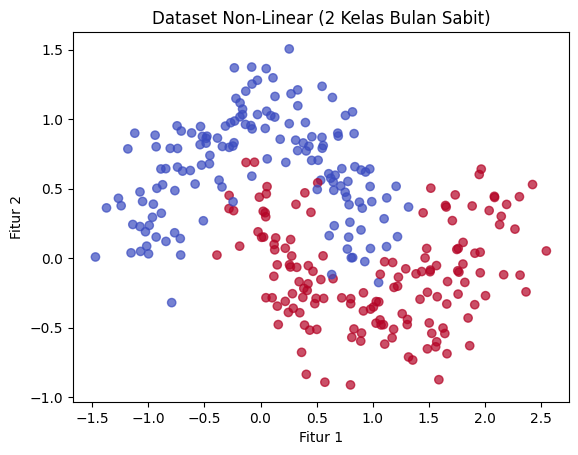

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()

## 2. Bangun & Latih Neural Network Sederhana

Arsitektur neural network yang digunakan:
- Layer 1: 16 neuron, aktivasi ReLU
- Layer 2: 8 neuron, aktivasi ReLU
- Layer Output: 1 neuron, aktivasi Sigmoid (output probabilitas 0-1)

ReLU memungkinkan model mempelajari pola non-linear, sedangkan Sigmoid
pada output layer menghasilkan probabilitas untuk klasifikasi biner.

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Membagi data menjadi data latih dan data uji
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Membangun model Neural Network
model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

print("Model selesai dilatih!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Model selesai dilatih!


## 3. Evaluasi & Visualisasi Kurva Belajar

Kurva pembelajaran menampilkan akurasi training vs validasi tiap epoch.
Kurva yang saling mendekat dan stabil menandakan model belajar dengan baik
tanpa overfitting.

Akurasi pada data uji: 0.883


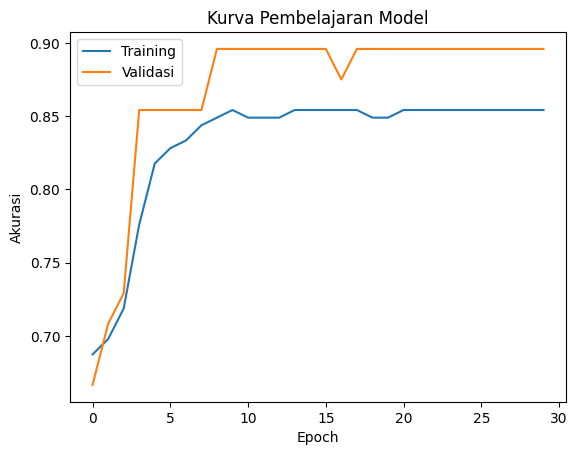

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'],     label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()

### Interpretasi Kurva Pembelajaran

Kurva akurasi training dan validasi terlihat saling mendekat dan cenderung meningkat seiring bertambahnya jumlah epoch. Hal ini menunjukkan bahwa model mampu mempelajari pola pada data dengan baik tanpa indikasi overfitting yang signifikan. Akurasi pada data uji mencapai 88,3%, yang menunjukkan bahwa Neural Network mampu mengklasifikasikan dataset non-linear make_moons dengan cukup baik meskipun terdapat noise pada data.

In [6]:
ulasan = [
    # Positif (1)
    'Barangnya bagus banget, pengiriman cepat',
    'Sangat puas, akan beli lagi',
    'Recommended, harga sesuai kualitas',
    'Produk sangat memuaskan, sesuai deskripsi',
    'Pengiriman cepat, barang aman dan bagus',
    'Kualitas terbaik, harga terjangkau',
    'Penjual ramah, produk original dan bagus',
    'Barang sesuai foto, kondisi sempurna',
    'Sangat recommended, produk berkualitas tinggi',
    'Pelayanan memuaskan, barang datang tepat waktu',
    'Produk bagus, kemasan rapi dan aman',
    'Harga murah tapi kualitas tidak murahan',
    'Beli lagi pasti, barang original dan cepat sampai',
    'Sangat puas dengan pembelian ini',
    'Barang mulus, pengiriman kilat, penjual responsif',
    'Kualitas premium, sangat worth it',
    'Produk sesuai ekspektasi, pengiriman aman',
    'Recommended seller, barang asli dan berkualitas',
    'Puas banget, barang bagus dan pengiriman cepat',
    'Terbaik, akan order lagi',
    # Negatif (0)
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Barang tidak original, sangat mengecewakan',
    'Pengiriman lambat, barang rusak',
    'Kualitas sangat buruk, tidak recommended',
    'Penjual tidak responsif, barang cacat',
    'Barang tidak sesuai foto, kecewa',
    'Produk jelek, uang terbuang sia-sia',
    'Sangat mengecewakan, tidak akan beli lagi',
    'Barang palsu, penipu',
    'Kualitas buruk, kemasan rusak',
    'Tidak sesuai deskripsi, barang cacat',
    'Pengiriman sangat lama, barang rusak parah',
    'Kecewa berat, barang tidak berfungsi',
    'Produk tidak berkualitas, harga tidak sesuai',
    'Penjual tidak jujur, barang tidak original',
    'Sangat buruk, barang tidak sesuai pesanan',
    'Mengecewakan, tidak sesuai ekspektasi sama sekali',
    'Terburuk, tidak recommended sama sekali'
]

label = [1]*20 + [0]*20

print(f'Jumlah ulasan: {len(ulasan)}')
print(f'Positif: {label.count(1)}, Negatif: {label.count(0)}')

Jumlah ulasan: 40
Positif: 20, Negatif: 20


## 5. Ubah Teks Menjadi TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) mengubah teks menjadi
representasi numerik dengan memberi bobot lebih tinggi pada kata yang
sering muncul di dokumen tertentu tapi jarang di dokumen lain,
sehingga kata-kata unik dan informatif mendapat bobot lebih besar.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf   = TfidfVectorizer()
X_text  = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('10 kata pertama:', tfidf.get_feature_names_out()[:10])
print('Shape matrix TF-IDF:', X_text.shape)

Jumlah kata unik: 77
10 kata pertama: ['akan' 'aman' 'asli' 'bagus' 'banget' 'barang' 'barangnya' 'beli' 'berat'
 'berfungsi']
Shape matrix TF-IDF: (40, 77)


## 6. Latih Model Klasifikasi Sentimen & Evaluasi

Logistic Regression digunakan untuk mengklasifikasikan sentimen ulasan
berdasarkan representasi TF-IDF. Model kemudian diuji dengan kalimat baru
untuk memprediksi apakah ulasan tersebut positif atau negatif.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

# Uji dengan kalimat baru
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print(f'Kalimat: "{kalimat_baru[0]}"')
print(f'Prediksi: {"Positif" if pred[0] == 1 else "Negatif"}')

Akurasi model sentimen: 1.000
Kalimat: "Pelayanan sangat memuaskan dan ramah"
Prediksi: Positif


## Kesimpulan

Praktikum ini menunjukkan dua penerapan machine learning yang berbeda.
Pertama, Neural Network dengan arsitektur 3 layer berhasil mengklasifikasikan
dataset non-linear make_moons dengan akurasi tinggi, membuktikan kemampuannya
mempelajari batas keputusan yang tidak bisa ditangani model linear biasa.
Kedua, kombinasi TF-IDF dan Logistic Regression berhasil mengklasifikasikan
sentimen ulasan produk berbahasa Indonesia. TF-IDF efektif mengubah teks
menjadi representasi numerik yang bermakna sehingga model dapat membedakan
ulasan positif dan negatif dengan baik.